Generating data for N politicians...


Surveys: 100%|██████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 16.27it/s]


Data generated: 10000 politicians
True ideal points range: [-3.92, 3.93]
Step    100	Mean Training Loss:7.0655651
Rec Loss:7.0522327
Divergence Loss:0.0133324
Pred Loss:0.0000000

Step    200	Mean Training Loss:7.0334530
Rec Loss:7.0203123
Divergence Loss:0.0131409
Pred Loss:0.0000000

Step    300	Mean Training Loss:0.7252418
Rec Loss:0.7195765
Divergence Loss:0.0056652
Pred Loss:0.0000000

Step    400	Mean Training Loss:7.7100296
Rec Loss:7.6971102
Divergence Loss:0.0129193
Pred Loss:0.0000000

Step    500	Mean Training Loss:7.6899934
Rec Loss:7.6767569
Divergence Loss:0.0132364
Pred Loss:0.0000000

Step    600	Mean Training Loss:0.7055115
Rec Loss:0.7010705
Divergence Loss:0.0044410
Pred Loss:0.0000000

Step    700	Mean Training Loss:0.6974440
Rec Loss:0.6923265
Divergence Loss:0.0051176
Pred Loss:0.0000000

Step    800	Mean Training Loss:6.9503384
Rec Loss:6.9381094
Divergence Loss:0.0122290
Pred Loss:0.0000000

Step    900	Mean Training Loss:0.6709121
Rec Loss:0.6633253
Divergence 

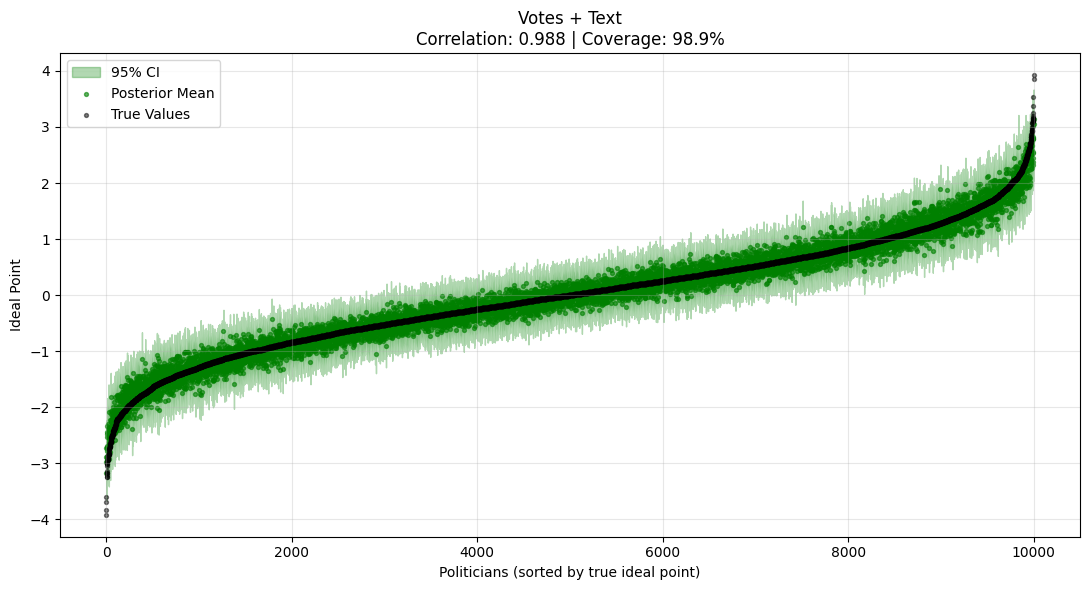

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from deeplatent import generate_ideal_points, Corpus, IdealPointNN

# --------------------------------------------------------------------
# 1. Generate simulated data
# --------------------------------------------------------------------

np.random.seed(42)

NUM_BILLS = 1000
NUM_SURVEY_QUESTIONS = 2
DOC_LENGTH = 100
VOCAB_SIZE = 1000

print("Generating data for N politicians...")
ideal_points, df, word_matrix, beta, label_coeffs = generate_ideal_points(
    num_politicians=10000,
    dim_ideal_points=1,
    num_bills=NUM_BILLS,
    num_survey_questions=NUM_SURVEY_QUESTIONS,
    doc_length=DOC_LENGTH,
    vocab_size=VOCAB_SIZE,
    progress_bar=True
)

print(f"Data generated: {df.shape[0]} politicians")
print(f"True ideal points range: [{ideal_points.min():.2f}, {ideal_points.max():.2f}]")

# --------------------------------------------------------------------
# 2. Vectorize text
# --------------------------------------------------------------------

vectorizer = CountVectorizer()
vectorizer.fit(df["doc_clean"])

# --------------------------------------------------------------------
# 3. Build corpus manually (votes + text)
# --------------------------------------------------------------------

modalities = {
    "text": {
        "column": "doc_clean",
        "views": {
            "bow": {
                "type": "bow",
                "vectorizer": vectorizer
            }
        }
    },
    "vote": {
        "column": [f"vote_{i+1}" for i in range(NUM_BILLS)],
        "views": {
            "responses": {
                "type": "vote"
            }
        }
    }
}

corpus = Corpus(df, modalities=modalities)

# --------------------------------------------------------------------
# 4. Build encoder_args and decoder_args
# --------------------------------------------------------------------

encoder_args = {}
decoder_args = {}

for modality in corpus.modalities_config.keys():
    for view in corpus.modalities_config[modality]["views"].keys():
        key = f"{modality}_{view}"
        encoder_args[key] = {
            "hidden_dims": [128,64],
            "activation": "relu",
            "bias": True,
            "dropout": 0.0
        }
        decoder_args[key] = {
            "hidden_dims": [],
            "activation": "relu",
            "bias": True,
            "dropout": 0.0
        }
            
# --------------------------------------------------------------------
# 5. Train model
# --------------------------------------------------------------------

model = IdealPointNN(
    ae_type="vae",
    vi_type="iaf",
    update_prior=False,
    n_ideal_points=1,
    batch_size=100,
    train_data=corpus,
    encoder_args=encoder_args,
    decoder_args=decoder_args,
    print_every_n_steps=100,
    num_steps=5000,
    return_best_model=True,
    w_prior=0.01,
    fusion="corrected_poe",
    seed=12345
)

# --------------------------------------------------------------------
# 6. Extract latent ideal points (with uncertainty)
# --------------------------------------------------------------------

z = model.get_ideal_points(corpus, num_samples=200, return_samples=True)

means_raw = z.mean(axis=1).flatten()
true = ideal_points[:, 0].flatten()

# Affine alignment
c = np.cov(true, means_raw, bias=True)[0,1] / np.var(means_raw, ddof=0)
d = np.mean(true) - c * np.mean(means_raw)

z_corrected = c * z + d

means = z_corrected.mean(axis=1).flatten()
ses = z_corrected.std(axis=1).flatten()

correlation = np.corrcoef(means, true)[0, 1]
coverage = np.mean((true >= means - 1.96*ses) & (true <= means + 1.96*ses))

print(f"Correlation: {correlation:.3f}, Coverage: {coverage:.3f}")

weights = model.get_modality_weights(corpus) 
modality_names = list(model.encoder.encoders.keys()) # e.g., ['text_bow', 'vote_responses'] 
df_weights = pd.DataFrame(weights, 
                          columns=modality_names) 
summary = pd.DataFrame({ "mean": df_weights.mean(), 
                         "std": df_weights.std() }).sort_values("mean", 
                                                                ascending=False) 
print(summary)

weights = model.get_mutual_information(corpus) 
modality_names = list(model.encoder.encoders.keys()) # e.g., ['text_bow', 'vote_responses'] 
df_weights = pd.DataFrame(weights, 
                          columns=modality_names) 
summary = pd.DataFrame({ "mean": df_weights.mean(), 
                         "std": df_weights.std() }).sort_values("mean", 
                                                                ascending=False) 
print(summary)

# --------------------------------------------------------------------
# 7. Visualize sorted ideal points (joint)
# --------------------------------------------------------------------

order = np.argsort(true)
true_sorted = true[order]
mean_sorted = means[order]
se_sorted = ses[order]

plt.figure(figsize=(11,6))

plt.fill_between(
    np.arange(len(true_sorted)),
    mean_sorted - 1.96 * se_sorted,
    mean_sorted + 1.96 * se_sorted,
    alpha=0.3,
    color="green",
    label="95% CI"
)

plt.scatter(np.arange(len(true_sorted)), mean_sorted,
            s=8, alpha=0.6, color="green", label="Posterior Mean")

plt.scatter(np.arange(len(true_sorted)), true_sorted,
            s=8, alpha=0.5, color="black", label="True Values")

plt.title(f"Votes + Text\nCorrelation: {correlation:.3f} | Coverage: {coverage*100:.1f}%")
plt.xlabel("Politicians (sorted by true ideal point)")
plt.ylabel("Ideal Point")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

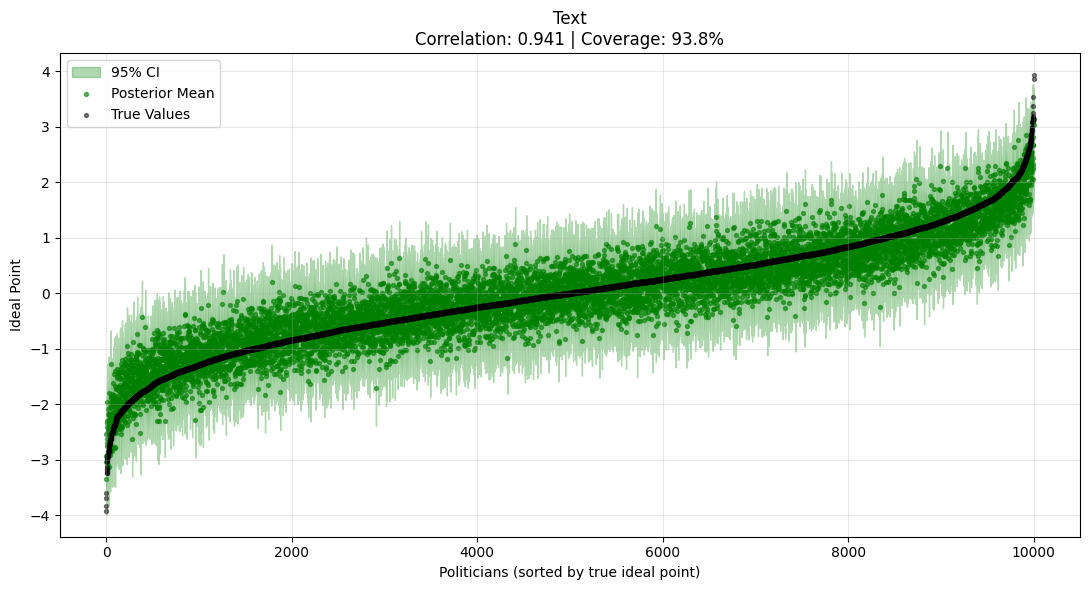

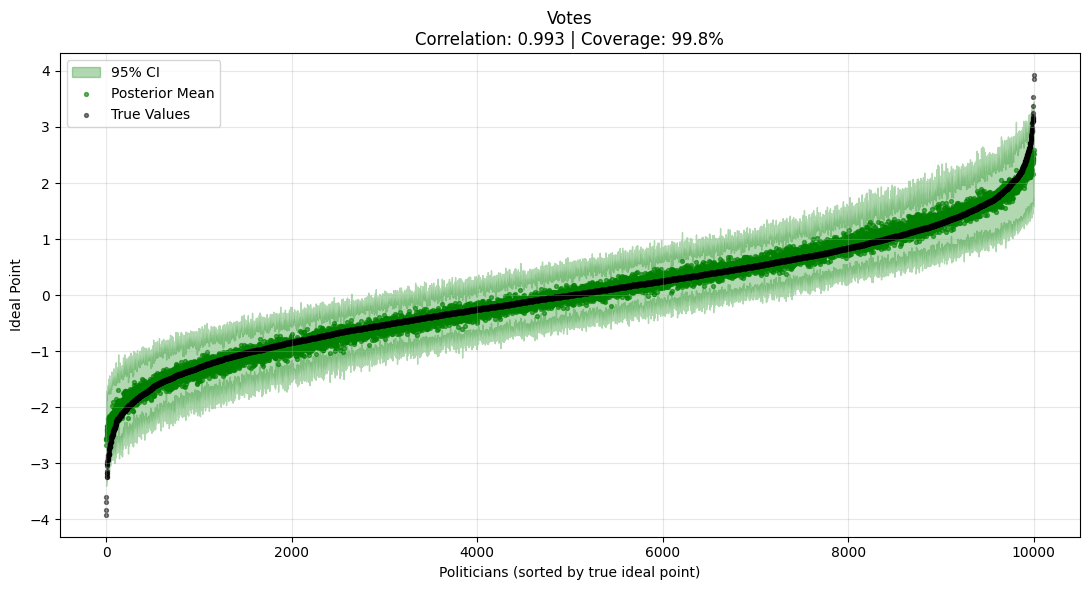

In [2]:
# --------------------------------------------------------------------
# Visualize sorted ideal points (just text)
# --------------------------------------------------------------------

z = model.get_ideal_points(corpus, single_modality = "text_bow", num_samples=200, return_samples=True)

means_raw = z.mean(axis=1).flatten()
true = ideal_points[:, 0].flatten()

# Affine alignment
c = np.cov(true, means_raw, bias=True)[0,1] / np.var(means_raw, ddof=0)
d = np.mean(true) - c * np.mean(means_raw)

z_corrected = c * z + d

means = z_corrected.mean(axis=1).flatten()
ses = z_corrected.std(axis=1).flatten()

correlation = np.corrcoef(means, true)[0, 1]
coverage = np.mean((true >= means - 1.96*ses) & (true <= means + 1.96*ses))

order = np.argsort(true)
true_sorted = true[order]
mean_sorted = means[order]
se_sorted = ses[order]

plt.figure(figsize=(11,6))

plt.fill_between(
    np.arange(len(true_sorted)),
    mean_sorted - 1.96 * se_sorted,
    mean_sorted + 1.96 * se_sorted,
    alpha=0.3,
    color="green",
    label="95% CI"
)

plt.scatter(np.arange(len(true_sorted)), mean_sorted,
            s=8, alpha=0.6, color="green", label="Posterior Mean")

plt.scatter(np.arange(len(true_sorted)), true_sorted,
            s=8, alpha=0.5, color="black", label="True Values")

plt.title(f"Text\nCorrelation: {correlation:.3f} | Coverage: {coverage*100:.1f}%")
plt.xlabel("Politicians (sorted by true ideal point)")
plt.ylabel("Ideal Point")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# Visualize sorted ideal points (just votes)
# --------------------------------------------------------------------

z = model.get_ideal_points(corpus, single_modality = "vote_responses", num_samples=200, return_samples=True)

means_raw = z.mean(axis=1).flatten()
true = ideal_points[:, 0].flatten()

# Affine alignment
c = np.cov(true, means_raw, bias=True)[0,1] / np.var(means_raw, ddof=0)
d = np.mean(true) - c * np.mean(means_raw)

z_corrected = c * z + d

means = z_corrected.mean(axis=1).flatten()
ses = z_corrected.std(axis=1).flatten()

correlation = np.corrcoef(means, true)[0, 1]
coverage = np.mean((true >= means - 1.96*ses) & (true <= means + 1.96*ses))

order = np.argsort(true)
true_sorted = true[order]
mean_sorted = means[order]
se_sorted = ses[order]

plt.figure(figsize=(11,6))

plt.fill_between(
    np.arange(len(true_sorted)),
    mean_sorted - 1.96 * se_sorted,
    mean_sorted + 1.96 * se_sorted,
    alpha=0.3,
    color="green",
    label="95% CI"
)

plt.scatter(np.arange(len(true_sorted)), mean_sorted,
            s=8, alpha=0.6, color="green", label="Posterior Mean")

plt.scatter(np.arange(len(true_sorted)), true_sorted,
            s=8, alpha=0.5, color="black", label="True Values")

plt.title(f"Votes\nCorrelation: {correlation:.3f} | Coverage: {coverage*100:.1f}%")
plt.xlabel("Politicians (sorted by true ideal point)")
plt.ylabel("Ideal Point")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()